# Final Project: Precipitation Anomalies, Drought Episodes, and Vegetation Response in Marsabit County, Kenya (1981–2022)
#### Xiao Ma (xm2357)

### (1) Scientific Question 
How did seasonal precipitation anomalies in Marsabit County, Kenya, vary from 1981 to 2022, and to what extent did major drought periods coincide with vegetation stress as measured by Normalized Difference Vegetation Index (NDVI) anomalies?
### (2) Hypothesis: 
 Major drought periods in Marsabit County will correspond to strongly negative seasonal precipitation anomalies, and these rainfall deficits will be associated with reduced NDVI, especially when drought persists across consecutive seasons.
### (3) Datasets
Rainfall: CHIRPS(version 2.0) monthly precipitation (1981–present)
https://www.chc.ucsb.edu/data/chirps

Vegetation: NDVI(MOD13A3.061)Layers 1KM monthly (2009-2022)
https://search.earthdata.nasa.gov/searchq=MODIS%20NDVIs


### Analysis plan
1. Analyze seasonal precipitation anomalies (two rainfall seasons) in Marsabit County (1981–2022).
Plot time series of seasonal precipitation anomalies for the main rainy seasons to identify long-term variability, dry periods, and unusually wet seasons.
2. Compare selected drought episodes. Examine the 2010–2011, 2016–2017, and 2021–2022 drought periods to assess whether these widely recognized drought episodes in Kenya appear as strong or persistent negative precipitation anomalies in Marsabit.
3. Examine rainfall and vegetation anomalies together. Plot precipitation anomalies and NDVI anomalies over time to evaluate whether vegetation stress occurs during or after rainfall deficits.
4. Examine the relationship between precipitation and NDVI. Compare precipitation anomalies with NDVI anomalies, using scatter plots to test whether drier seasons are associated with lower vegetation greenness.

In [45]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rioxarray
import numpy as np

### Rainfall data prcoess
CHIRPS Version 2.0, monthly precipitation from 1981 to 2025

In [2]:
chirps_path ="/Users/xiao/File/For_P/project_K/chrips/chirps-v2.0.monthly.nc"
shape_path = "/Users/xiao/File/For_P/project_K/boundary/kenya_admin/ken_admin_boundaries.shp/ken_admin1.shp"

In [3]:
kenya = gpd.read_file("/Users/xiao/File/For_P/project_K/boundary/kenya_admin/ken_admin_boundaries.shp/ken_admin1.shp")
kenya.head()

,adm1_name,adm1_name1,adm1_name2,adm1_name3,adm1_pcode,adm0_name,adm0_name1,adm0_name2,adm0_name3,adm0_pcode,...,area_sqkm,cod_versio,lang,lang1,lang2,lang3,adm1_ref_n,center_lat,center_lon,geometry
0,Baringo,None,None,None,KE030,Kenya,None,None,None,KE,...,10889.239313,V_01,en,None,None,None,Baringo,0.726352,36.018591,"POLYGON ((35.7839 1.65557, 35.78496 1.65554, 3..."
1,Bomet,None,None,None,KE036,Kenya,None,None,None,KE,...,2438.219727,V_01,en,None,None,None,Bomet,-0.716095,35.238459,"POLYGON ((35.4736 -0.3992, 35.47845 -0.40663, ..."
2,Bungoma,None,None,None,KE039,Kenya,None,None,None,KE,...,3016.174229,V_01,en,None,None,None,Bungoma,0.785694,34.718757,"POLYGON ((34.62017 1.10228, 34.62133 1.1016, 3..."
3,Busia,None,None,None,KE040,Kenya,None,None,None,KE,...,1811.571693,V_01,en,None,None,None,Busia,0.375707,34.265111,"POLYGON ((34.36097 0.7773, 34.36172 0.77696, 3..."
4,Elgeyo-Marakwet,None,None,None,KE028,Kenya,None,None,None,KE,...,3008.391184,V_01,en,None,None,None,Elgeyo-Marakwet,0.745102,35.560856,"POLYGON ((35.69818 1.28225, 35.69788 1.27905, ..."


In [ ]:
kenya.columns #check shapefiles, Marsabit is in adm1_name

Index(['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',
       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',
       'valid_on', 'valid_to', 'area_sqkm', 'cod_versio', 'lang', 'lang1',
       'lang2', 'lang3', 'adm1_ref_n', 'center_lat', 'center_lon', 'geometry'],
      dtype='str')

In [5]:
marsabit = kenya[kenya["adm1_name"] == "Marsabit"]

In [7]:
marsabit = marsabit.to_crs("EPSG:4326") 
#Transform all geometries in an active geometry column to a different coordinate reference system

In [ ]:
ds = xr.open_dataset(chirps_path) # read CHIRPS data
print(ds)

<xarray.Dataset> Size: 31GB
Dimensions:    (time: 542, latitude: 2000, longitude: 7200)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2026-02-01
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    precip     (time, latitude, longitude) float32 31GB ...
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2026-03-16
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given month.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/ch

In [11]:
da = ds["precip"]
da = da.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude") #rioxarray
da = da.rio.write_crs("EPSG:4326")

In [ ]:
clipped = da.rio.clip(marsabit.geometry, marsabit.crs, drop=True) # clipe 

In [21]:
print(marsabit.crs)
print(da.rio.crs)

EPSG:4326
EPSG:4326


In [22]:
marsabit = marsabit.to_crs("EPSG:4326")

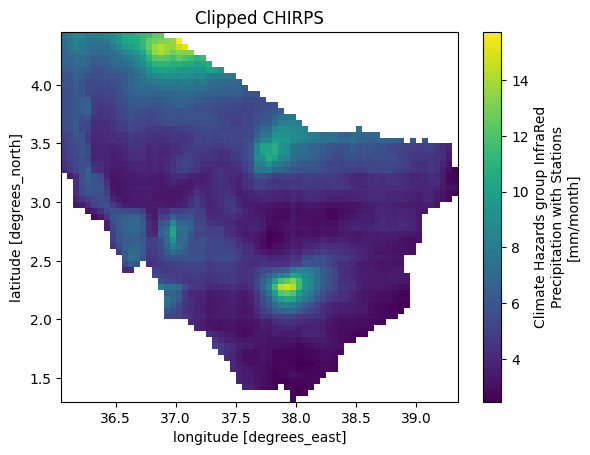

In [167]:
clipped.isel(time=0).plot()
plt.title("Clipped CHIRPS")
plt.show()

In [13]:
marsabit_mean = clipped.mean(dim=["latitude", "longitude"]) # montly precipitaion(mean)

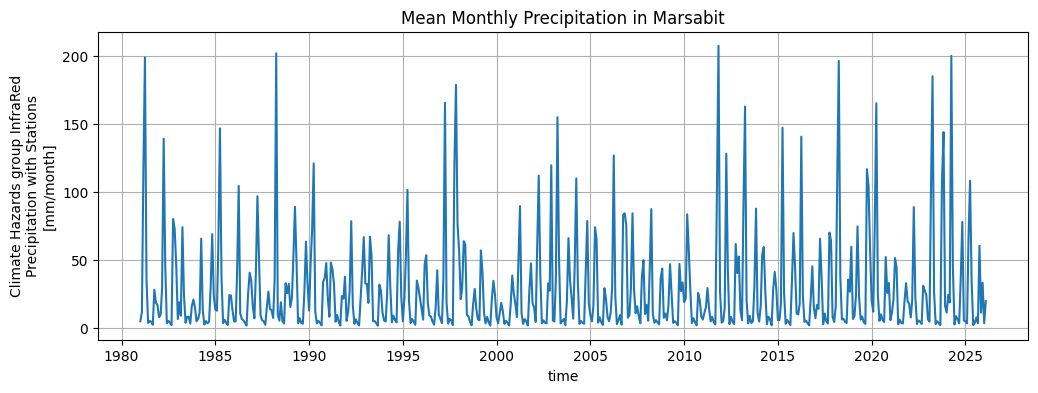

In [ ]:
# monthly precipitation plot (1981- 02/2026)
marsabit_mean.plot(figsize=(12, 4))
plt.title("Mean Monthly Precipitation in Marsabit")
plt.grid(True)
plt.show(

In [ ]:
df = marsabit_mean.to_dataframe(name="precip").reset_index() # convert to dataframe
print(df.tail()) # check the latest month

          time  spatial_ref     precip
537 2025-10-01            0  60.434681
538 2025-11-01            0  11.332181
539 2025-12-01            0  33.387253
540 2026-01-01            0   3.602072
541 2026-02-01            0  19.813831


In [18]:
df.to_csv("/Users/xiao/File/For_P/project_K/chrips/marsabit_mean_precip.csv", index=False) #export to csv.file

In [19]:
df = pd.read_csv('/Users/xiao/File/For_P/project_K/chrips/marsabit_mean_precip.csv', parse_dates=['time'])
df.head()

,time,spatial_ref,precip
0,1981-01-01,0,5.023474
1,1981-02-01,0,11.831643
2,1981-03-01,0,114.491590
3,1981-04-01,0,198.875080
4,1981-05-01,0,36.284378


In [21]:
df.tail()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time         542 non-null    datetime64[us]
 1   spatial_ref  542 non-null    int64         
 2   precip       542 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 12.8 KB


In [22]:
print(df.columns)
print(df["time"].min(), df["time"].max())


Index(['time', 'spatial_ref', 'precip'], dtype='str')
1981-01-01 00:00:00 2026-02-01 00:00:00


In [ ]:
df["year"] = df["time"].dt.year # add year and month column
df["month"] = df["time"].dt.month
df.head()

,time,spatial_ref,precip,year,month
0,1981-01-01,0,5.023474,1981,1
1,1981-02-01,0,11.831643,1981,2
2,1981-03-01,0,114.491590,1981,3
3,1981-04-01,0,198.875080,1981,4
4,1981-05-01,0,36.284378,1981,5


In [24]:
df.tail()


,time,spatial_ref,precip,year,month
537,2025-10-01,0,60.434680,2025,10
538,2025-11-01,0,11.332181,2025,11
539,2025-12-01,0,33.387253,2025,12
540,2026-01-01,0,3.602072,2026,1
541,2026-02-01,0,19.813831,2026,2


In [25]:
#drop 2026 entirely
df = df[df['year']<= 2025 ]

### Kenya has two rainfall seasons: 
long rains season: MAM (March, April, May) and the short rains season OND (October, November, December) 

In [27]:
#Select MAM and OND
mam= df[df['month'].isin([3,4,5])]
ond=df[df['month'].isin([10,11,12])]

In [31]:
#Calculate seasonal totals
mam_seasonal= mam.groupby('year')['precip'].sum()
ond_seasonal= ond.groupby('year')['precip'].sum()

In [32]:
#Define baseline (1981-2010)
mam_baseline = mam_seasonal.loc[1981:2010].mean()
ond_baseline = ond_seasonal.loc[1981:2010].mean()

In [ ]:
#Compute seasonal anomalies (%)
mam_anom =(mam_seasonal - mam_baseline )/ mam_baseline * 100
ond_anom =(ond_seasonal - ond_baseline)/ ond_baseline * 100

In [ ]:
# MAM Top5 droughts
mam_top5 = mam_anom.nsmallest(5) # nmallest
mam_top5

year
2000   -74.971895
2011   -64.348399
2009   -46.942612
1984   -45.882444
1983   -35.476122
Name: precip, dtype: float64

In [37]:
#OND Top5 droughts
ond_Top5 = ond_anom.nsmallest(5)
ond_Top5

year
1983   -53.450667
2010   -51.135518
1987   -49.928112
2005   -47.642589
1998   -45.725757
Name: precip, dtype: float64

### Analyze seasonal precipitation anomalies in Marsabit County (1981–2022)
Plot time series of seasonal precipitation anomalies for the main rainy seasons to identify long-term variability, dry periods, and unusually wet seasons.

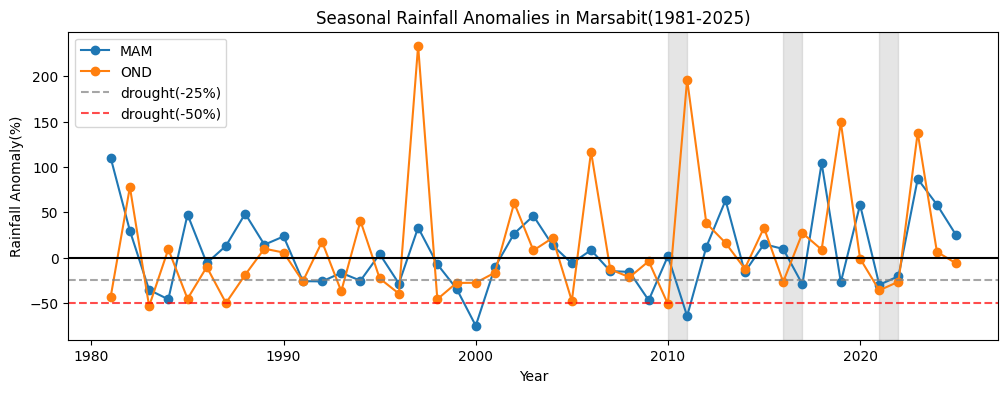

In [69]:
plt.figure(figsize=(12,4))
plt.plot(mam_anom.index, mam_anom, label='MAM',marker="o")
plt.plot(ond_anom.index,ond_anom,label='OND',marker="o")
plt.axhline(0,linestyle='-',color='black')
plt.xlabel('Year')
plt.ylabel('Rainfall Anomaly(%)')
plt.title("Seasonal Rainfall Anomalies in Marsabit(1981-2025)")
#Highlight drought thresholds
plt.axhline(-25, linestyle='--', color='grey', alpha=0.7, label='drought(-25%)',linewidth=1.5)
plt.axhline(-50, linestyle='--', color='red', alpha=0.7,label='drought(-50%)',linewidth=1.5)
# Highlight drought periods
plt.axvspan(2010, 2011, alpha=0.2,color="grey")
plt.axvspan(2016, 2017, alpha=0.2,color="grey")
plt.axvspan(2021, 2022, alpha=0.2,color="grey")
plt.legend()

### Result
The plot shows that drought risk in Marsabit is characterized by frequent moderate rainfall deficits and their persistence across seasons, rather than being dominated by rare extreme events

###  Compare selected drought episodes.

In [64]:
def subset_period(start, end):
    return mam_anom.loc[start:end],ond_anom.loc[start:end]

mam_1011, ond_1011 = subset_period(2008, 2013)
mam_1617, ond_1671 = subset_period(2014, 2019)
mam_2122, ond_2211 = subset_period(2019, 2024)

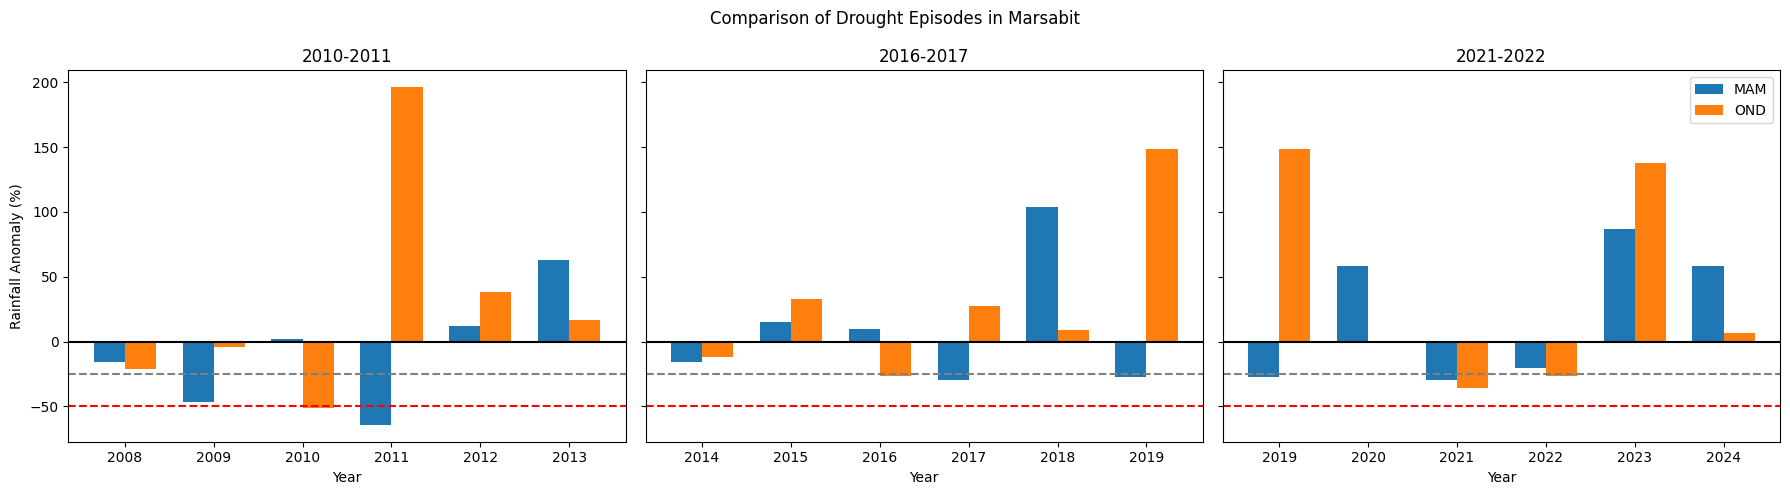

In [173]:
fig, axes = plt.subplots(1, 3,figsize=(18,5),sharey=True)

cases = [
    (mam_1011, ond_1011, '2010-2011'),
    (mam_1617, ond_1671, '2016-2017'),
    (mam_2122, ond_2211, '2021-2022')
    ]

for ax, (mam, ond, title) in zip(axes, cases):

    years = mam.index.astype(str)
    x = np.arange(len(years))
    width = 0.35

    ax.bar(
        x - width/2,
        mam.values,
        width,
        label='MAM'
    )
    ax.bar(
        x + width/2,
        ond.values,
        width,
        label='OND'
    )
    ax.axhline(0, color='black')

    ax.axhline(
        -25,
        linestyle='--',
        color='grey'
    )
    ax.axhline(
        -50,
        linestyle='--',
        color='red'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.set_title(title)
    ax.set_xlabel('Year')

axes[0].set_ylabel('Rainfall Anomaly (%)')

plt.suptitle('Comparison of Drought Episodes in Marsabit')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Result
(1)The 2010–2011 drought period in Marsabit was characterized by strong seasonal contrasts, with severe MAM rainfall deficits despite wetter OND conditions in 2011.
(2)The 2016–2017 event was characterized more by repeated moderate seasonal deficits rather than a single extreme drought season.
(3)The 2021–2022 drought period exhibited persistent below-average conditions across multiple seasons, although anomalies were generally less extreme than the 2010–2011 event.

### Vegetation response

#### Vegetation: NDVI
Marsabit_NDVI Layers 1KM monthly NDVI(MOD13A3.061) 
NDVI downloaded by using the Marsabit boundary

In [90]:
import glob

In [99]:
files = sorted(glob.glob("/Users/xiao/File/For_P/project_K/NDVI/*.tif"))
da_list = []
time_list = []

for f in files:
    da = rioxarray.open_rasterio(f,masked=True).squeeze() #masked=True means: “Automatically recognize missing/fill values and convert them into NaN-like masked values so they are ignored in calculations.”
    da = da * 0.0001
    fname = os.path.basename(f)
    doy = fname.split("doy")[1][:7]
    time = pd.to_datetime(doy, format="%Y%j")
    
    da_list.append(da)
    time_list.append(time)

ndvi = xr.concat(da_list, dim="time")
ndvi = ndvi.assign_coords(time=time_list)


In [100]:
print(da)

<xarray.DataArray (y: 384, x: 371)> Size: 570kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(384, 371), dtype=float32)
Coordinates:
  * y            (y) float64 3kB 4.479 4.471 4.462 4.454 ... 1.304 1.296 1.287
  * x            (x) float64 3kB 36.2 36.2 36.21 36.22 ... 39.26 39.27 39.28
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    add_offset:     0.0
    scale_factor:   1.0
    units:          NA
    AREA_OR_POINT:  Area


In [97]:
da.attrs

{'add_offset': 0.0,
 'scale_factor': 1.0,
 'units': 'NA',
 'AREA_OR_POINT': 'Area'}

In [ ]:
ndvi.min().item(), ndvi.max().item() # the max value looks not correct, maybe still some NA vule here

(-0.19999998807907104, 5.734299659729004)

In [102]:
da = rioxarray.open_rasterio(f, masked=True).squeeze()
da = da * 0.0001

# keep only physically meaningful NDVI values
da = da.where((da >= -1) & (da <= 1))

In [ ]:
#re-run
da_list = []
time_list = []

for f in files:
    da = rioxarray.open_rasterio(f, masked=True).squeeze()
    da = da * 0.0001
    da = da.where((da >= -1) & (da <= 1))

    fname = os.path.basename(f)
    doy = fname.split("doy")[1][:7]
    time = pd.to_datetime(doy, format="%Y%j")

    da_list.append(da)
    time_list.append(time)

ndvi = xr.concat(da_list, dim="time")
ndvi = ndvi.assign_coords(time=time_list)

In [ ]:
ndvi.min().item(), ndvi.max().item() # this feels right

(-0.19999998807907104, 0.9565999507904053)

In [105]:
#calculate the spatial mean NDVI time series
ndvi_mean = ndvi.mean(dim=["x", "y"], skipna=True)

In [ ]:
ndvi_df = ndvi_mean.to_dataframe(name="ndvi").reset_index()

ndvi_df["time"].is_monotonic_increasing

False

In [112]:
ndvi_df = ndvi_df.sort_values("time")

In [ ]:
ndvi_df["time"].duplicated().sum() #Clean duplicate/sorting issues

np.int64(168)

In [114]:
ndvi_df = (
    ndvi_df
    .groupby("time", as_index=False)["ndvi"]
    .mean()
)

In [118]:
navi_baseline = ndvi_df["ndvi"].mean() #calculates the mean NDVI across the whole record
navi_baseline

np.float32(0.22116601)

In [122]:
# add NDVI anomalies
ndvi_df["ndvi_anom"] = (
    (ndvi_df["ndvi"] - navi_baseline) / navi_baseline
) * 100
ndvi_df

,time,ndvi,ndvi_anom
0,2009-01-01,0.204489,-7.540452
1,2009-02-01,0.200030,-9.556541
2,2009-03-01,0.194214,-12.186441
3,2009-04-01,0.209077,-5.466137
4,2009-05-01,0.205144,-7.244290
...,...,...,...
163,2022-08-01,0.187604,-15.175028
164,2022-09-01,0.185950,-15.922882
165,2022-10-01,0.185529,-16.113163
166,2022-11-01,0.198911,-10.062767


### Plot NDVI Anomalies in Marsabit (2009-2022)

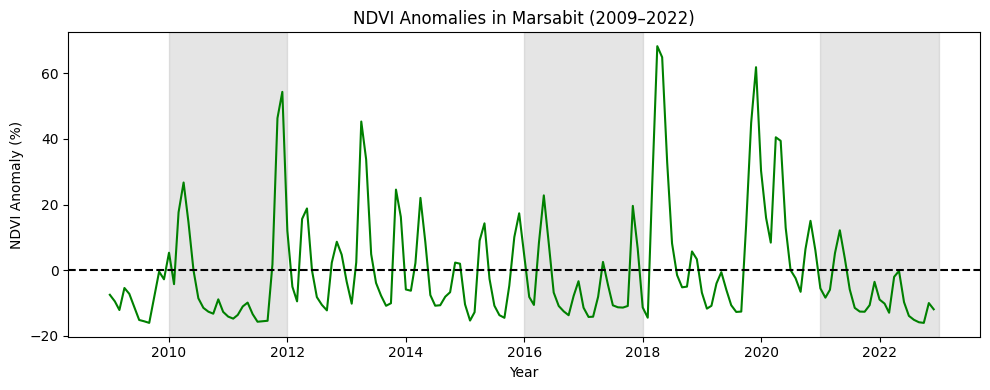

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(
    ndvi_df["time"],
    ndvi_df["ndvi_anom"],
    color="green",
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

# Highlight drought periods
plt.axvspan(
    pd.Timestamp("2010-01-01"),
    pd.Timestamp("2011-12-31"),
    alpha=0.2,
    color="grey"
)

plt.axvspan(
    pd.Timestamp("2016-01-01"),
    pd.Timestamp("2017-12-31"),
    alpha=0.2,
    color="grey"
)

plt.axvspan(
    pd.Timestamp("2021-01-01"),
    pd.Timestamp("2022-12-31"),
    alpha=0.2,
    color="grey"
)

plt.title("NDVI Anomalies in Marsabit (2009-2022)")
plt.ylabel("NDVI Anomaly (%)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

### Result
During the drought periods(2010-2011, 2016-2017, 2021-2022), the vegetaion conditons were getting worse. 

In [124]:
# Make sure NDVI dataframe has year/month
ndvi_df["year"] = ndvi_df["time"].dt.year
ndvi_df["month"] = ndvi_df["time"].dt.month

# Overall NDVI anomaly
baseline_ndvi = ndvi_df["ndvi"].mean()
ndvi_df["ndvi_anom"] = ((ndvi_df["ndvi"] - baseline_ndvi) / baseline_ndvi) * 100

In [128]:
mam_ndvi = (
    ndvi_df[ndvi_df["month"].isin([3,4,5])]
    .groupby("year")["ndvi"]
    .mean()
)

In [129]:
ond_ndvi = (
    ndvi_df[ndvi_df["month"].isin([10,11,12])]
    .groupby("year")["ndvi"]
    .mean()
)

In [130]:
mam_baseline = mam_ndvi.mean()
ond_baseline = ond_ndvi.mean()

mam_ndvi_anom = ((mam_ndvi - mam_baseline) / mam_baseline) * 100
ond_ndvi_anom = ((ond_ndvi - ond_baseline) / ond_baseline) * 100

### Plot the relationship between droughts and vegetation response

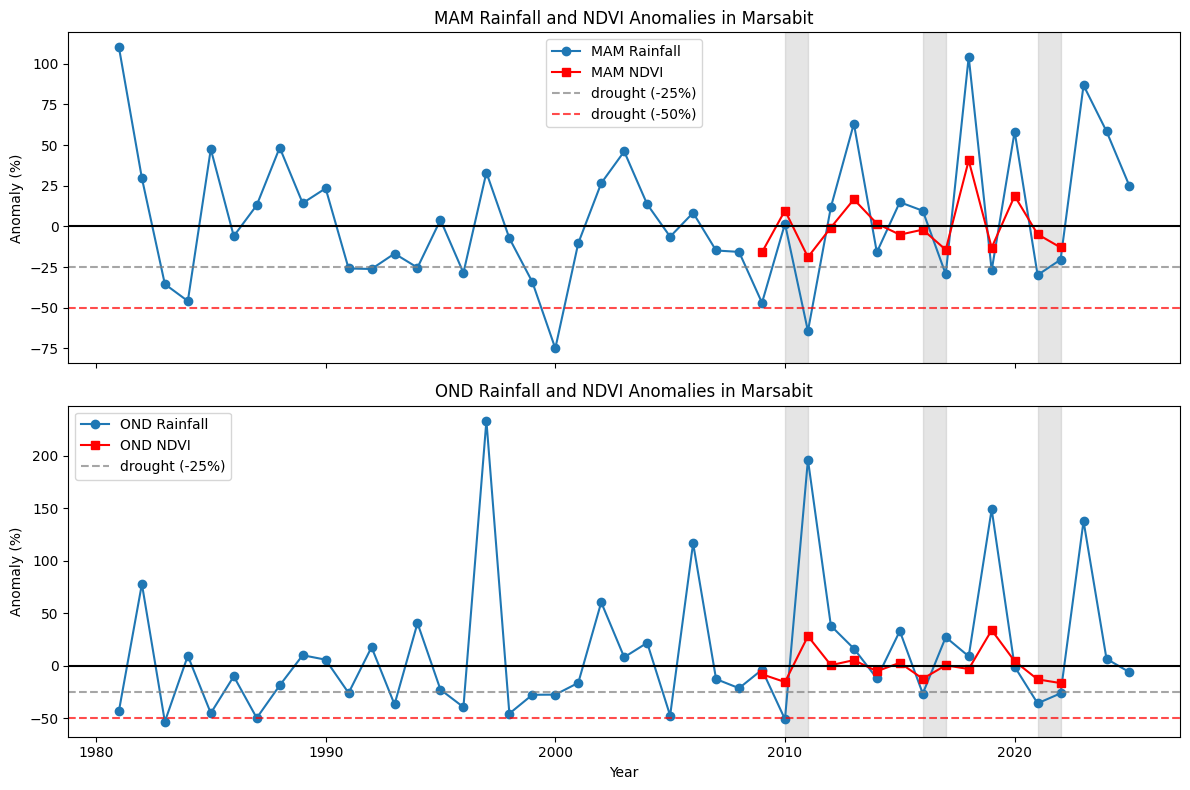

In [174]:
fig, ax = plt.subplots(
    2, 1,
    figsize=(12,8),
    sharex=True
)

# Panel 1: MAM

ax[0].plot(
    mam_anom.index.astype(int),
    mam_anom.values,
    label="MAM Rainfall",
    marker="o"
)

ax[0].plot(
    mam_ndvi_anom.index,
    mam_ndvi_anom.values,
    color='red',
    label="MAM NDVI",
    marker="s"
)

ax[0].axhline(0, color="black")

ax[0].axhline(
    -25,
    linestyle="--",
    color="grey",
    alpha=0.7,
    label="drought (-25%)"
)

ax[0].axhline(
    -50,
    linestyle="--",
    color="red",
    alpha=0.7,
    label="drought (-50%)"
)

ax[0].set_ylabel("Anomaly (%)")

ax[0].set_title(
    "MAM Rainfall and NDVI Anomalies in Marsabit"
)

ax[0].legend()

# Panel 2: OND

ax[1].plot(
    ond_anom.index.astype(int),
    ond_anom.values,
    label="OND Rainfall",
    marker="o"
)

ax[1].plot(
    ond_ndvi_anom.index,
    ond_ndvi_anom.values,
    color='red',
    label="OND NDVI",
    marker="s"
)

ax[1].axhline(0, color="black")

ax[1].axhline(
    -25,
    linestyle="--",
    color="grey",
    alpha=0.7,
    label="drought (-25%)"
)

ax[1].axhline(
    -50,
    linestyle="--",
    color="red",
    alpha=0.7
)

ax[1].set_ylabel("Anomaly (%)")
ax[1].set_xlabel("Year")
ax[1].set_title("OND Rainfall and NDVI Anomalies in Marsabit")
ax[1].legend()

# Highlight drought periods
for a in ax:
    a.axvspan(2010, 2011, alpha=0.2, color="grey")
    a.axvspan(2016, 2017, alpha=0.2, color="grey")
    a.axvspan(2021, 2022, alpha=0.2, color="grey")

plt.tight_layout()
plt.show()

### Result
NDVI anomalies generally follow the direction of rainfall anomalies suggesting that vegetation conditions are influenced by seasonal rainfall variability. 

### Scatter plot: rainfall anomaly vs NDVI anomaly

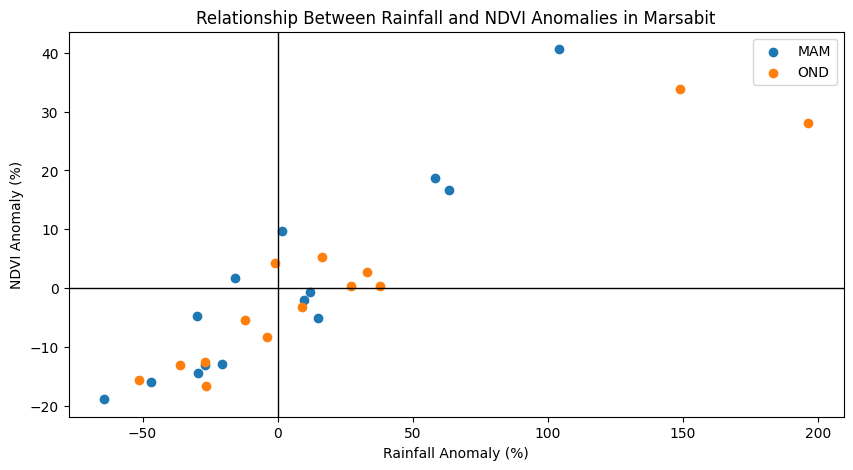

In [145]:
plt.figure(figsize=(10,5))

plt.scatter(mam_anom.loc[mam_ndvi_anom.index], mam_ndvi_anom, label="MAM")
plt.scatter(ond_anom.loc[ond_ndvi_anom.index], ond_ndvi_anom, label="OND")

plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Rainfall Anomaly (%)")
plt.ylabel("NDVI Anomaly (%)")
plt.title("Relationship Between Rainfall and NDVI Anomalies in Marsabit")
plt.legend()
plt.show()

### Result
Seasonal NDVI anomalies show a strong positive relationship with rainfall anomalies
